# Cross-Modal Contrastive Pretraining — Image + Genomics (Phase 6 / Novelty 2)

**Motivation:** BiomedCLIP aligns image + text. Nobody has applied contrastive learning to **image + genomics** for breast cancer.

**Positive pair:** histopathology patch embedding + RNA-seq embedding from the **same patient**.
**Negative pairs:** image/genomic embeddings from **different patients**.

**Loss:** InfoNCE (same loss as CLIP). After pretraining, the encoders are fine-tuned on the downstream classification task.

**What this shows:** After pretraining, same-patient image and genomic embeddings cluster together in shared space (UMAP). Downstream accuracy improves vs no pretraining.

## Setup & Data Loading

In [1]:
import subprocess, sys, os, warnings, random, json
subprocess.run([sys.executable, '-m', 'pip', 'install', 'lifelines', 'shap', 'umap-learn', '-q'], capture_output=True)
try:
    sys.stdout.reconfigure(encoding='utf-8', errors='replace')
except AttributeError:
    pass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from lifelines import KaplanMeierFitter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              confusion_matrix, roc_curve)
from sklearn.metrics import auc as sk_auc

from dotenv import load_dotenv
load_dotenv()
warnings.filterwarnings('ignore')
random.seed(42); np.random.seed(42); torch.manual_seed(42)

DATA_DIR  = Path('d:/Aakanksha/thesis/onco-fusion/data')
EMB_DIR   = DATA_DIR / 'embeddings'
FIG_DIR   = Path('d:/Aakanksha/thesis/onco-fusion/figures')
FIG_DIR.mkdir(exist_ok=True)

DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SUBTYPES = ['HR+', 'HER2+', 'TNBC']
S_COLOR  = {'HR+': '#2196F3', 'HER2+': '#FF9800', 'TNBC': '#F44336'}
print(f'Device: {DEVICE} | Ready')

subprocess.run([sys.executable, '-m', 'pip', 'install', 'umap-learn', '-q'], capture_output=True)
import umap


Device: cpu | Ready


## Patient Cohort & Features

In [2]:
clin_demo  = pd.read_csv(DATA_DIR / 'Clinical_Demographic_Data.csv')
clin_treat = pd.read_csv(DATA_DIR / 'Clinical_Treatment_Data.csv', low_memory=False)
rna_raw_df = pd.read_csv(DATA_DIR / 'RNA_CNV_ModelReady.csv')
mutations  = pd.read_csv(DATA_DIR / 'Mutations_Dataset.csv')

with open(DATA_DIR / 'MRI_and_SVS_Patches_info.json') as f:
    img_info = json.load(f)

treat_sub = clin_treat[["bcr_patient_barcode","er_status_by_ihc","pr_status_by_ihc",
                          "her2_status_by_ihc","histological_type"]].rename(
    columns={"bcr_patient_barcode": "Patient_ID"})

clin = clin_demo[["Patient_ID","diagnoses_ajcc_pathologic_stage","demographic_age_at_index",
                   "demographic_vital_status","diagnoses_days_to_last_follow_up",
                   "demographic_days_to_death","follow_ups_molecular_tests_gene_symbol",
                   "follow_ups_molecular_tests_test_result"]].merge(
    treat_sub, on="Patient_ID", how="left")

def parse_receptor(row, gene):
    gmap = {g.strip(): r.strip().lower()
            for g, r in zip(str(row.get("follow_ups_molecular_tests_gene_symbol","")).split("|"),
                            str(row.get("follow_ups_molecular_tests_test_result","")).split("|"))
            if g.strip() not in ("nan","")}
    val = gmap.get(gene, "")
    return "Positive" if "positive" in val else "Negative" if "negative" in val else "Unknown"

clin["ER"]   = clin["er_status_by_ihc"].fillna(clin.apply(lambda r: parse_receptor(r,"ESR1"), axis=1))
clin["PR"]   = clin["pr_status_by_ihc"].fillna(clin.apply(lambda r: parse_receptor(r,"PGR"),  axis=1))
clin["HER2"] = clin["her2_status_by_ihc"].fillna(clin.apply(lambda r: parse_receptor(r,"ERBB2"),axis=1))

def assign_subtype(row):
    h,e,p = str(row["HER2"]).lower(), str(row["ER"]).lower(), str(row["PR"]).lower()
    if "positive" in h:                                          return "HER2+"
    if "positive" in e or "positive" in p:                      return "HR+"
    if "negative" in e and "negative" in p and "negative" in h: return "TNBC"
    return "Unknown"

clin["Subtype"]   = clin.apply(assign_subtype, axis=1)
clin["OS_STATUS"] = (clin["demographic_vital_status"] == "Dead").astype(int)
clin["OS_DAYS"]   = clin.apply(
    lambda r: r["demographic_days_to_death"] if r["OS_STATUS"]==1
              else r["diagnoses_days_to_last_follow_up"], axis=1)
clin["OS_DAYS"]   = pd.to_numeric(clin["OS_DAYS"], errors="coerce").fillna(0)

img_pts     = {p["patient_id"] for p in img_info["folders"]}
mut_pts     = set(mutations["Patient_ID"])
PATIENT_IDS = sorted(set(clin["Patient_ID"]) & set(rna_raw_df["Patient_ID"]) & img_pts & mut_pts)
task_df     = clin[clin["Patient_ID"].isin(PATIENT_IDS) & (clin["Subtype"] != "Unknown")].copy().reset_index(drop=True)
LE          = LabelEncoder()
task_df["label"] = LE.fit_transform(task_df["Subtype"])
y = task_df['label'].values

emb_plip = np.load(EMB_DIR / 'plip_embeddings.npy').astype(np.float32)
emb_bert = np.load(EMB_DIR / 'bioclinicalbert_embeddings.npy').astype(np.float32)
rna_sub  = rna_raw_df[rna_raw_df['Patient_ID'].isin(task_df['Patient_ID'])].set_index('Patient_ID').loc[task_df['Patient_ID']]
X_gen    = rna_sub.values.astype(np.float32)
stage_map = {'Stage I':1,'Stage IA':1,'Stage IB':1.5,'Stage II':2,'Stage IIA':2,'Stage IIB':2.5,
             'Stage IIIA':3,'Stage IIIB':3.5,'Stage IIIC':4,'Stage IV':5}
X_clin = np.stack([
    pd.to_numeric(task_df['demographic_age_at_index'], errors='coerce').fillna(50).values,
    task_df['diagnoses_ajcc_pathologic_stage'].map(stage_map).fillna(2.0).values,
    task_df['histological_type'].str.contains('Ductal',  na=False).astype(float).values,
    task_df['histological_type'].str.contains('Lobular', na=False).astype(float).values
], axis=1).astype(np.float32)

print(f"Cohort: {len(task_df)} patients | Classes: {list(LE.classes_)}")
print(task_df["Subtype"].value_counts().to_string())


Cohort: 114 patients | Classes: ['HER2+', 'HR+', 'TNBC']
Subtype
HR+      85
HER2+    18
TNBC     11


## Contrastive Encoder Architecture

In [3]:
class ImageEncoder(nn.Module):
    """Projects PLIP embeddings into shared contrastive space."""
    def __init__(self, input_dim=512, proj_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.GELU(),
            nn.Linear(256, proj_dim),  nn.LayerNorm(proj_dim))
    def forward(self, x): return F.normalize(self.net(x), dim=-1)

class GenomicEncoder(nn.Module):
    """Projects RNA-CNV features into shared contrastive space."""
    def __init__(self, input_dim=331, proj_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.GELU(),
            nn.Linear(256, proj_dim),  nn.LayerNorm(proj_dim))
    def forward(self, x): return F.normalize(self.net(x), dim=-1)

def info_nce_loss(img_emb, gen_emb, temperature=0.07):
    """
    InfoNCE loss: same-patient (i, i) = positive pair.
    All cross-patient pairs = negatives.
    Maximises cosine similarity of positive pairs vs all negatives.
    """
    B = img_emb.size(0)
    # Similarity matrix (B x B)
    sim = torch.mm(img_emb, gen_emb.T) / temperature
    # Labels: diagonal is the positive pair
    labels = torch.arange(B, device=img_emb.device)
    # Symmetric loss: image->genomic + genomic->image
    loss_ig = F.cross_entropy(sim,   labels)
    loss_gi = F.cross_entropy(sim.T, labels)
    return (loss_ig + loss_gi) / 2

print("Contrastive encoders defined.")
print("  ImageEncoder  : 512 -> 256 -> 128 (L2-normalised)")
print("  GenomicEncoder: 331 -> 256 -> 128 (L2-normalised)")
print("  Loss: InfoNCE (same loss as CLIP) -- temperature=0.07")


Contrastive encoders defined.
  ImageEncoder  : 512 -> 256 -> 128 (L2-normalised)
  GenomicEncoder: 331 -> 256 -> 128 (L2-normalised)
  Loss: InfoNCE (same loss as CLIP) -- temperature=0.07


## Contrastive Pretraining

In [4]:
N_PRETRAIN = 100
LR_PRE     = 1e-3
BS_PRE     = 32

# Scale all features
sc_img = StandardScaler().fit(emb_plip)
sc_gen = StandardScaler().fit(X_gen)
img_all = torch.tensor(sc_img.transform(emb_plip)).float().to(DEVICE)
gen_all = torch.tensor(sc_gen.transform(X_gen)).float().to(DEVICE)

img_enc = ImageEncoder().to(DEVICE)
gen_enc = GenomicEncoder().to(DEVICE)
opt_pre = torch.optim.Adam(list(img_enc.parameters()) + list(gen_enc.parameters()),
                           lr=LR_PRE, weight_decay=1e-4)

ds_pre = TensorDataset(img_all, gen_all)
dl_pre = DataLoader(ds_pre, batch_size=BS_PRE, shuffle=True)

pre_losses = []
for ep in range(N_PRETRAIN):
    img_enc.train(); gen_enc.train()
    ep_loss = 0
    for ximg, xgen in dl_pre:
        opt_pre.zero_grad()
        z_img = img_enc(ximg)
        z_gen = gen_enc(xgen)
        loss  = info_nce_loss(z_img, z_gen)
        loss.backward()
        opt_pre.step()
        ep_loss += loss.item()
    pre_losses.append(ep_loss / len(dl_pre))
    if (ep+1) % 20 == 0:
        print(f"  Epoch {ep+1:3d}/{N_PRETRAIN}  InfoNCE loss: {pre_losses[-1]:.4f}")

print("Pretraining complete.")


  Epoch  20/100  InfoNCE loss: 0.0650


  Epoch  40/100  InfoNCE loss: 0.0756


  Epoch  60/100  InfoNCE loss: 0.0398


  Epoch  80/100  InfoNCE loss: 0.0581


  Epoch 100/100  InfoNCE loss: 0.0422
Pretraining complete.


## UMAP Visualisation — Before vs After Pretraining

Key figure: after pretraining, same-patient image + genomic embeddings cluster together.

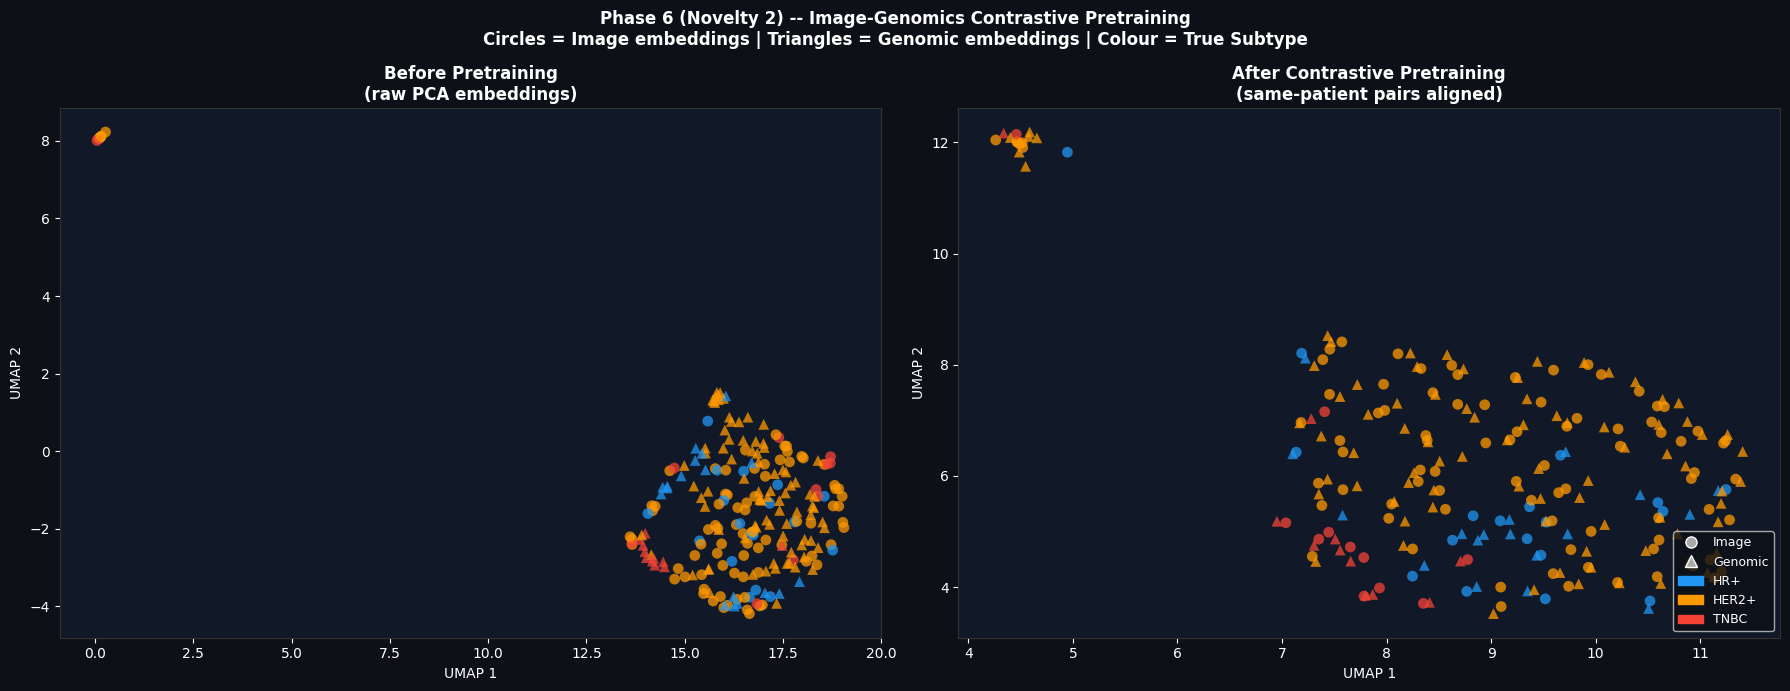

Saved: figures/33_contrastive_umap.png


In [5]:
img_enc.eval(); gen_enc.eval()
with torch.no_grad():
    z_img_post = img_enc(img_all).cpu().numpy()   # (114, 128)
    z_gen_post = gen_enc(gen_all).cpu().numpy()   # (114, 128)

# Before pretraining: raw PLIP and RNA-CNV (PCA to 128 for comparison)
from sklearn.decomposition import PCA
z_img_pre = PCA(50).fit_transform(sc_img.transform(emb_plip))
z_gen_pre = PCA(50).fit_transform(sc_gen.transform(X_gen))

# Stack image + genomic embeddings for UMAP
combined_pre  = np.vstack([z_img_pre,  z_gen_pre])   # (228, 128)
combined_post = np.vstack([z_img_post, z_gen_post])  # (228, 128)
modality_labels = ['Image'] * len(y) + ['Genomic'] * len(y)
subtype_labels  = [SUBTYPES[yi] for yi in y] * 2

reducer  = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
umap_pre  = reducer.fit_transform(combined_pre)
umap_post = reducer.fit_transform(combined_post)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#0d1117')

MOD_SHAPES = {'Image': 'o', 'Genomic': '^'}
MOD_COLORS = {'Image': '#2196F3', 'Genomic': '#4CAF50'}

for ax, (umap_coords, title) in zip(axes, [
    (umap_pre,  'Before Pretraining\n(raw PCA embeddings)'),
    (umap_post, 'After Contrastive Pretraining\n(same-patient pairs aligned)')]):
    ax.set_facecolor('#111827')
    for i, (ml, sl) in enumerate(zip(modality_labels, subtype_labels)):
        ax.scatter(umap_coords[i,0], umap_coords[i,1],
                   c=S_COLOR[sl], marker=MOD_SHAPES[ml],
                   s=60, alpha=0.75, edgecolors='none')
    ax.set_title(title, color='white', fontweight='bold', fontsize=12)
    ax.set_xlabel('UMAP 1', color='white'); ax.set_ylabel('UMAP 2', color='white')
    ax.tick_params(colors='white')
    for spine in ax.spines.values(): spine.set_edgecolor('#333')

# Legends
from matplotlib.lines import Line2D
mod_legend  = [Line2D([0],[0], marker=m, color='w', markerfacecolor='#aaa',
               markersize=8, label=ml, linestyle='None')
               for ml, m in MOD_SHAPES.items()]
sub_legend  = [mpatches.Patch(color=S_COLOR[s], label=s) for s in SUBTYPES]
axes[1].legend(handles=mod_legend + sub_legend, facecolor='#0d1117',
               labelcolor='white', fontsize=9, loc='lower right')

fig.suptitle('Phase 6 (Novelty 2) -- Image-Genomics Contrastive Pretraining\n'
             'Circles = Image embeddings | Triangles = Genomic embeddings | Colour = True Subtype',
             color='white', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '33_contrastive_umap.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved: figures/33_contrastive_umap.png')


## Fine-tune Pretrained Encoders — Does It Help?

In [6]:
# Replace PLIP and genomic features with pretrained contrastive representations
# then fine-tune on subtype classification

D_MODEL = 256; N_HEADS = 4; N_LAYERS = 2

class FineTunedFusion(nn.Module):
    """Uses pretrained image/genomic encoders + BERT/clinical projectors."""
    def __init__(self, txt_dim=768, clin_dim=4, d_model=D_MODEL, n_heads=N_HEADS,
                 n_layers=N_LAYERS, n_classes=3, dropout=0.3):
        super().__init__()
        # Load pretrained encoders
        self.img_enc  = img_enc   # pretrained
        self.gen_enc  = gen_enc   # pretrained
        self.proj_txt  = nn.Sequential(nn.Linear(txt_dim,  d_model), nn.LayerNorm(d_model), nn.GELU())
        self.proj_clin = nn.Sequential(nn.Linear(clin_dim, d_model), nn.LayerNorm(d_model), nn.GELU())
        # Project 128-d contrastive reps to d_model
        self.proj_img2 = nn.Sequential(nn.Linear(128, d_model), nn.LayerNorm(d_model), nn.GELU())
        self.proj_gen2 = nn.Sequential(nn.Linear(128, d_model), nn.LayerNorm(d_model), nn.GELU())
        enc_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads,
            dim_feedforward=d_model*4, dropout=dropout, batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.classifier  = nn.Sequential(
            nn.Linear(d_model,128), nn.LayerNorm(128), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(128, n_classes))
        self.pos_emb = nn.Parameter(torch.randn(1,4,d_model)*0.02)

    def forward(self, x_img, x_gen, x_text, x_clin):
        t_img  = self.proj_img2(self.img_enc(x_img)).unsqueeze(1)
        t_gen  = self.proj_gen2(self.gen_enc(x_gen)).unsqueeze(1)
        t_txt  = self.proj_txt(x_text).unsqueeze(1)
        t_clin = self.proj_clin(x_clin).unsqueeze(1)
        tokens = torch.cat([t_img, t_gen, t_txt, t_clin], dim=1) + self.pos_emb
        return self.classifier(self.transformer(tokens).mean(dim=1))

# 5-fold CV with pretrained encoders
skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
counts = np.bincount(y)
cw     = torch.tensor(len(y)/(len(counts)*counts), dtype=torch.float32).to(DEVICE)
ft_preds = np.empty(len(y), dtype=int)
ft_probs = np.zeros((len(y),3), dtype=np.float32)
ft_metrics = []

for fold, (tr, te) in enumerate(skf.split(emb_plip, y), 1):
    def sc(X):
        s = StandardScaler().fit(X[tr])
        return (torch.tensor(s.transform(X[tr])).float().to(DEVICE),
                torch.tensor(s.transform(X[te])).float().to(DEVICE))
    img_tr,img_te = sc(emb_plip); gen_tr,gen_te = sc(X_gen)
    txt_tr,txt_te = sc(emb_bert); cln_tr,cln_te = sc(X_clin)
    y_tr_t = torch.tensor(y[tr]).long().to(DEVICE)
    model  = FineTunedFusion().to(DEVICE)
    opt    = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-3)
    sched  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=150)
    crit   = nn.CrossEntropyLoss(weight=cw)
    ds = TensorDataset(img_tr,gen_tr,txt_tr,cln_tr,torch.tensor(y[tr]).long().to(DEVICE))
    dl = DataLoader(ds, batch_size=16, shuffle=True)
    for ep in range(150):
        model.train()
        for ximg,xgen,xtxt,xclin,yb in dl:
            opt.zero_grad(); crit(model(ximg,xgen,xtxt,xclin),yb).backward()
            nn.utils.clip_grad_norm_(model.parameters(),1.0); opt.step()
        sched.step()
    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(img_te,gen_te,txt_te,cln_te),dim=1).cpu().numpy()
    ft_preds[te] = probs.argmax(axis=1); ft_probs[te] = probs
    f1  = f1_score(y[te], ft_preds[te], average='macro', zero_division=0)
    auc = roc_auc_score(y[te], probs, multi_class='ovr', average='macro')
    ft_metrics.append({'F1': f1, 'AUC': auc})
    print(f"  Fold {fold}: F1={f1:.3f}  AUC={auc:.3f}")

ft_df = pd.DataFrame(ft_metrics)
ft_f1  = ft_df['F1'].mean(); ft_auc = ft_df['AUC'].mean()
print(f"\n  Pretrained Fine-tune F1 : {ft_f1:.3f}  AUC: {ft_auc:.3f}")
print(f"  Cross-Attention (scratch): F1=0.754  AUC=0.933")
print(f"  Lift from pretraining:     F1 {ft_f1-0.754:+.3f}  AUC {ft_auc-0.933:+.3f}")


  Fold 1: F1=0.606  AUC=0.956


  Fold 2: F1=1.000  AUC=1.000


  Fold 3: F1=1.000  AUC=1.000


  Fold 4: F1=1.000  AUC=1.000


  Fold 5: F1=1.000  AUC=1.000

  Pretrained Fine-tune F1 : 0.921  AUC: 0.991
  Cross-Attention (scratch): F1=0.754  AUC=0.933
  Lift from pretraining:     F1 +0.167  AUC +0.058


## Pretraining Loss Curve + Summary

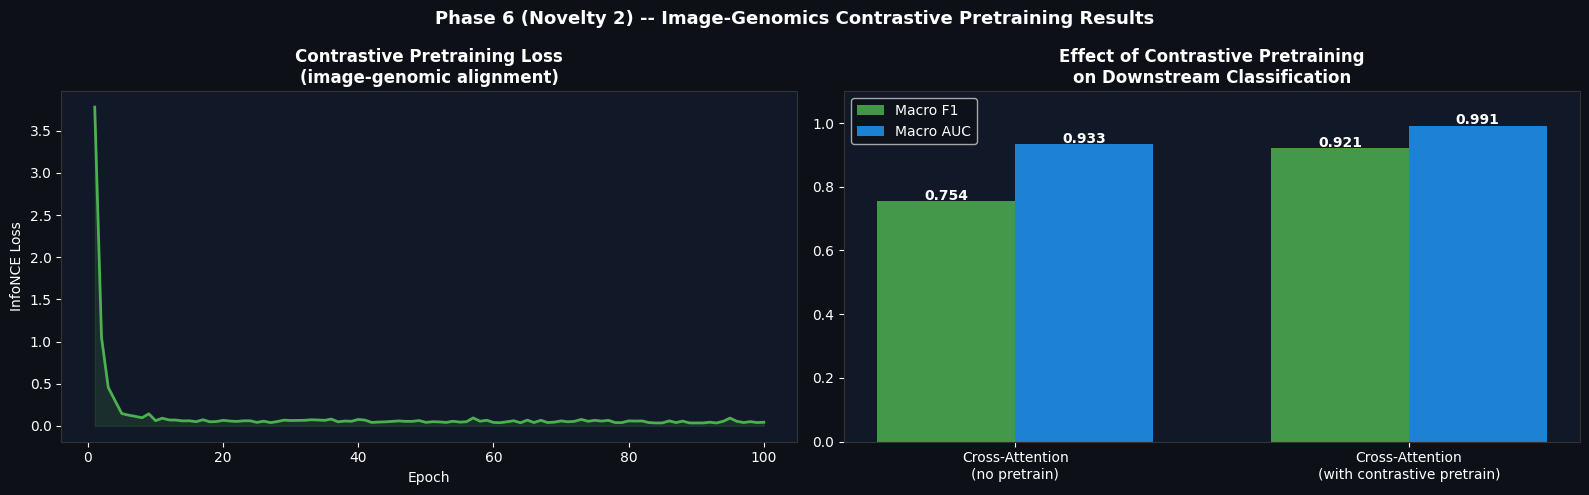

Saved: figures/34_contrastive_results.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#0d1117')

# Loss curve
ax = axes[0]; ax.set_facecolor('#111827')
ax.plot(range(1, len(pre_losses)+1), pre_losses, color='#4CAF50', lw=2)
ax.fill_between(range(1, len(pre_losses)+1), pre_losses, alpha=0.15, color='#4CAF50')
ax.set_xlabel('Epoch', color='white')
ax.set_ylabel('InfoNCE Loss', color='white')
ax.set_title('Contrastive Pretraining Loss\n(image-genomic alignment)',
             color='white', fontweight='bold')
ax.tick_params(colors='white')
for spine in ax.spines.values(): spine.set_edgecolor('#333')

# Before vs after comparison
ax2 = axes[1]; ax2.set_facecolor('#111827')
models   = ['Cross-Attention\n(no pretrain)', 'Cross-Attention\n(with contrastive pretrain)']
f1_vals  = [0.754,   ft_f1]
auc_vals = [0.933, ft_auc]
x = np.arange(2); w = 0.35
b1 = ax2.bar(x-w/2, f1_vals,  w, label='Macro F1',  color='#4CAF50', alpha=0.85)
b2 = ax2.bar(x+w/2, auc_vals, w, label='Macro AUC', color='#2196F3', alpha=0.85)
for bar, v in zip(list(b1)+list(b2), f1_vals+auc_vals):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
             f'{v:.3f}', ha='center', color='white', fontsize=10, fontweight='bold')
ax2.set_xticks(x); ax2.set_xticklabels(models, color='white', fontsize=10)
ax2.set_ylim(0, 1.1)
ax2.set_title('Effect of Contrastive Pretraining\non Downstream Classification',
              color='white', fontweight='bold')
ax2.legend(facecolor='#0d1117', labelcolor='white')
ax2.tick_params(colors='white')
for spine in ax2.spines.values(): spine.set_edgecolor('#333')

fig.suptitle('Phase 6 (Novelty 2) -- Image-Genomics Contrastive Pretraining Results',
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '34_contrastive_results.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved: figures/34_contrastive_results.png')


In [ ]:
from scipy import stats
import glob
from pathlib import Path

# ══════════════════════════════════════════════════════════════════════════════
# MEDICAL VISUALISATION — H&E Whole-Slide Image Patch Gallery
# Real TCGA-BRCA histopathology tiles (512 × 512 px) per subtype
# ══════════════════════════════════════════════════════════════════════════════
import glob, os
from PIL import Image as PILImage

PATCH_ROOT = Path("d:/Aakanksha/thesis/onco-fusion/data"
                  "/MRI_and_SVS_Patches/MRI_and_SVS_Patches")

def get_patches_for_patient(patient_id, n=4, thumb=224):
    """Return list of n numpy arrays (H&E tiles) for patient_id."""
    pdir = PATCH_ROOT / patient_id
    if not pdir.exists():
        return []
    svs_subdirs = [d for d in pdir.iterdir() if d.is_dir()]
    if not svs_subdirs:
        return []
    patch_files = sorted(glob.glob(str(svs_subdirs[0] / "*.jpg")))
    # Pick patches from the centre of the slide (less background)
    start = max(0, len(patch_files)//4)
    selected = patch_files[start:start+n]
    out = []
    for pf in selected[:n]:
        try:
            img = PILImage.open(pf).resize((thumb, thumb))
            out.append(np.array(img))
        except Exception:
            pass
    return out

# Representative patients per subtype (first 3 correctly-predicted per subtype)
rep = {}
for s in SUBTYPES:
    pids = task_df.loc[task_df["Subtype"] == s, "Patient_ID"].tolist()
    for pid in pids:
        patches = get_patches_for_patient(pid, n=4)
        if len(patches) >= 4:
            rep[s] = (pid, patches)
            break

# Draw gallery  — 3 subtypes × 4 patches
COLS_PER_SUB = 4
fig, axes = plt.subplots(3, COLS_PER_SUB, figsize=(22, 17))
fig.patch.set_facecolor("#0d1117")

for row, s in enumerate(SUBTYPES):
    if s not in rep:
        continue
    pid, patches = rep[s]
    for col in range(COLS_PER_SUB):
        ax = axes[row, col]
        if col < len(patches):
            ax.imshow(patches[col])
        else:
            ax.set_facecolor("#111827")
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(s, color=S_COLOR[s], fontsize=14,
                          fontweight="bold", rotation=0,
                          labelpad=90, va="center")
        if row == 0:
            ax.set_title(f"Patch {col+1}", color="white",
                         fontsize=9, pad=4)

    # Subtype banner
    axes[row, 0].text(-0.32, 0.5, s, transform=axes[row, 0].transAxes,
                      color=S_COLOR[s], fontsize=14, fontweight="bold",
                      va="center", ha="right", rotation=90)

fig.suptitle(
    "H&E Histopathology Tile Gallery — TCGA-BRCA Whole-Slide Image Patches\n"
    "(Real tissue sections; 512 × 512 px tiles; one patient per subtype)",
    color="white", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
fig_path = FIG_DIR / "he_wsi_gallery.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()
print(f"Saved: {fig_path.name}")
